In [2]:
library(igraph)
library(readxl)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [3]:
## Read excel 
became = data.frame(t(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=1)))

## Remove the first 10 columns (not lipids)
became_num = became[-c(1:10),]

## Cast data to numeric type 
rownames(became_num) = paste0('X',rownames(became_num))
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}


In [15]:
became = data.frame(t(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=1)))
became_meta = data.frame(t(became[c(1:4),]))

In [16]:
head(became_meta)

,Metabolites,Compound.Name,Lipid.ID,Lipid.suclasses
,<chr>,<chr>,<chr>,<chr>
X1,M371.3091T6.48,POS:371.3091@6.48,C14:0 Car,Acylcarnitines
X2,M369.2935T5.09,POS:369.2935@5.09,C14:1 Car,Acylcarnitines
X3,M399.3402T8.70,POS:399.3402@8.70,C16:0 Car,Acylcarnitines
X4,M427.3721T10.46,POS:427.3721@10.46,C18:0 Car,Acylcarnitines
X5,M425.3575T9.18,POS:425.3575@9.18,C18:1 Car,Acylcarnitines
X6,M423.3400T7.96,POS:423.3400@7.96,C18:2 Car,Acylcarnitines


In [4]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')
importance = read.csv('../data/var_importance.b1.csv')

became_data = scaled_df[rownames(subset(meta,cohort=='BECAME' & group=='HFpEF')),]

,Metabolites,Compound.Name,Lipid ID,Lipid suclasses
X1,M371.3091T6.48,POS:371.3091@6.48,C14:0 Car,Acylcarnitines
X2,M369.2935T5.09,POS:369.2935@5.09,C14:1 Car,Acylcarnitines
X3,M399.3402T8.70,POS:399.3402@8.70,C16:0 Car,Acylcarnitines
X4,M427.3721T10.46,POS:427.3721@10.46,C18:0 Car,Acylcarnitines
X5,M425.3575T9.18,POS:425.3575@9.18,C18:1 Car,Acylcarnitines
X6,M423.3400T7.96,POS:423.3400@7.96,C18:2 Car,Acylcarnitines


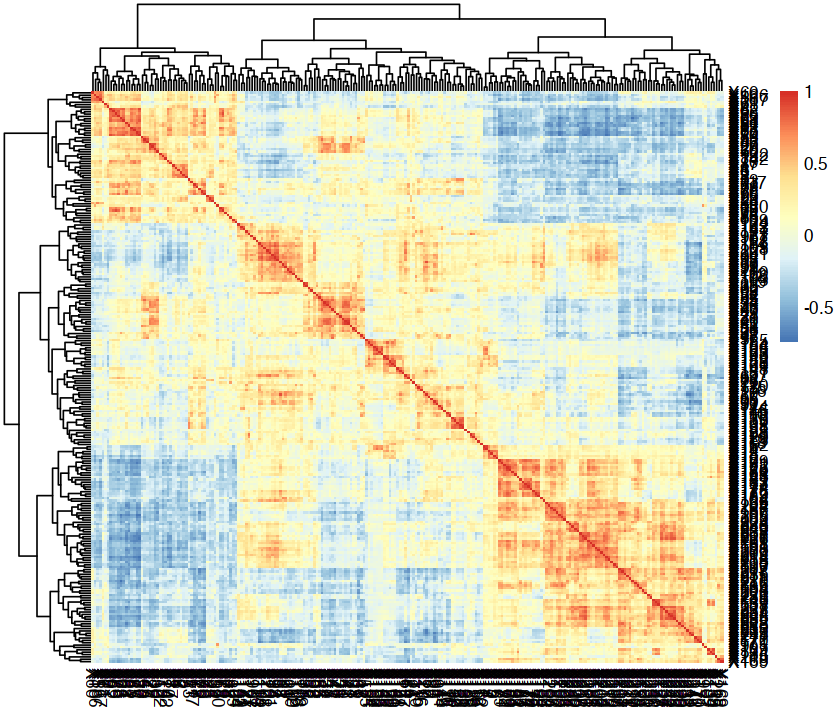

In [5]:
options(repr.plot.width = 7, repr.plot.height = 6)
became_data = log(became_num[rownames(became_data),])

mat <- cor(became_data)
pheatmap::pheatmap(mat)

In [17]:
library(RColorBrewer)

n <- nlevels(as.factor(became_meta$Lipid.suclasses))
qual_col_pals = brewer.pal.info[brewer.pal.info$category == 'qual',]
col_vector = unlist(mapply(brewer.pal, qual_col_pals$maxcolors, rownames(qual_col_pals)))
col_vector = sample(col_vector, n)

# Map the color to cylinders
my_color <- col_vector[as.numeric(as.factor(importance[rownames(mat),'lipid_class']))]

In [18]:
names(col_vector) = unique(importance[rownames(mat),'lipid_class'])

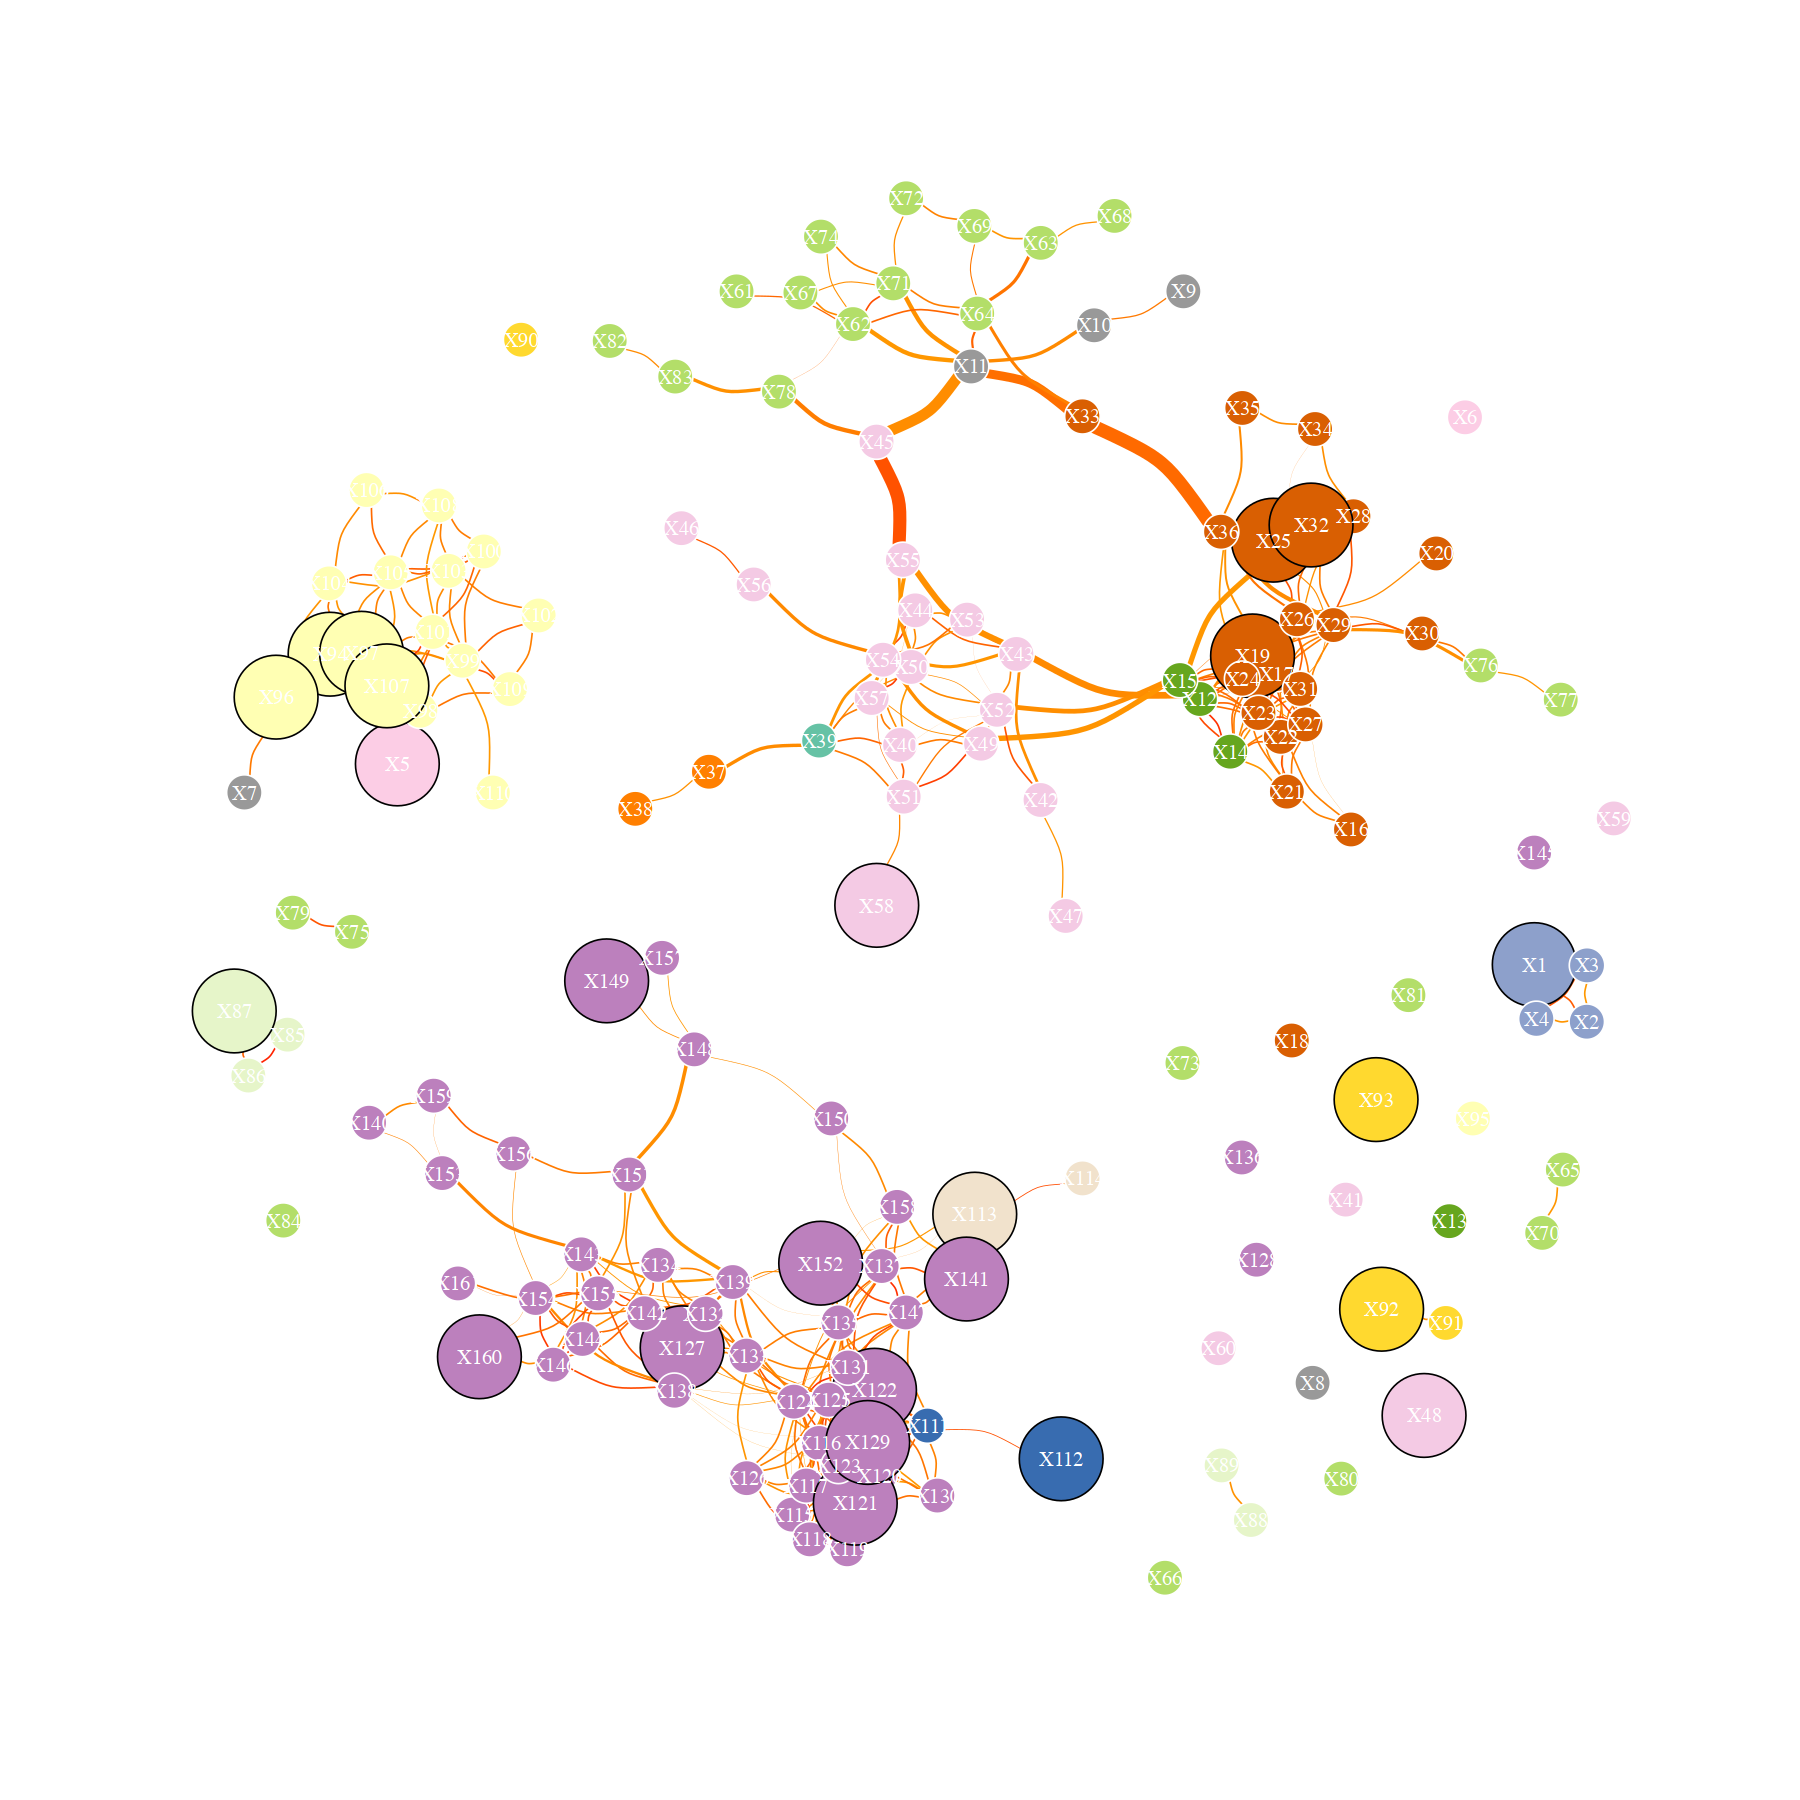

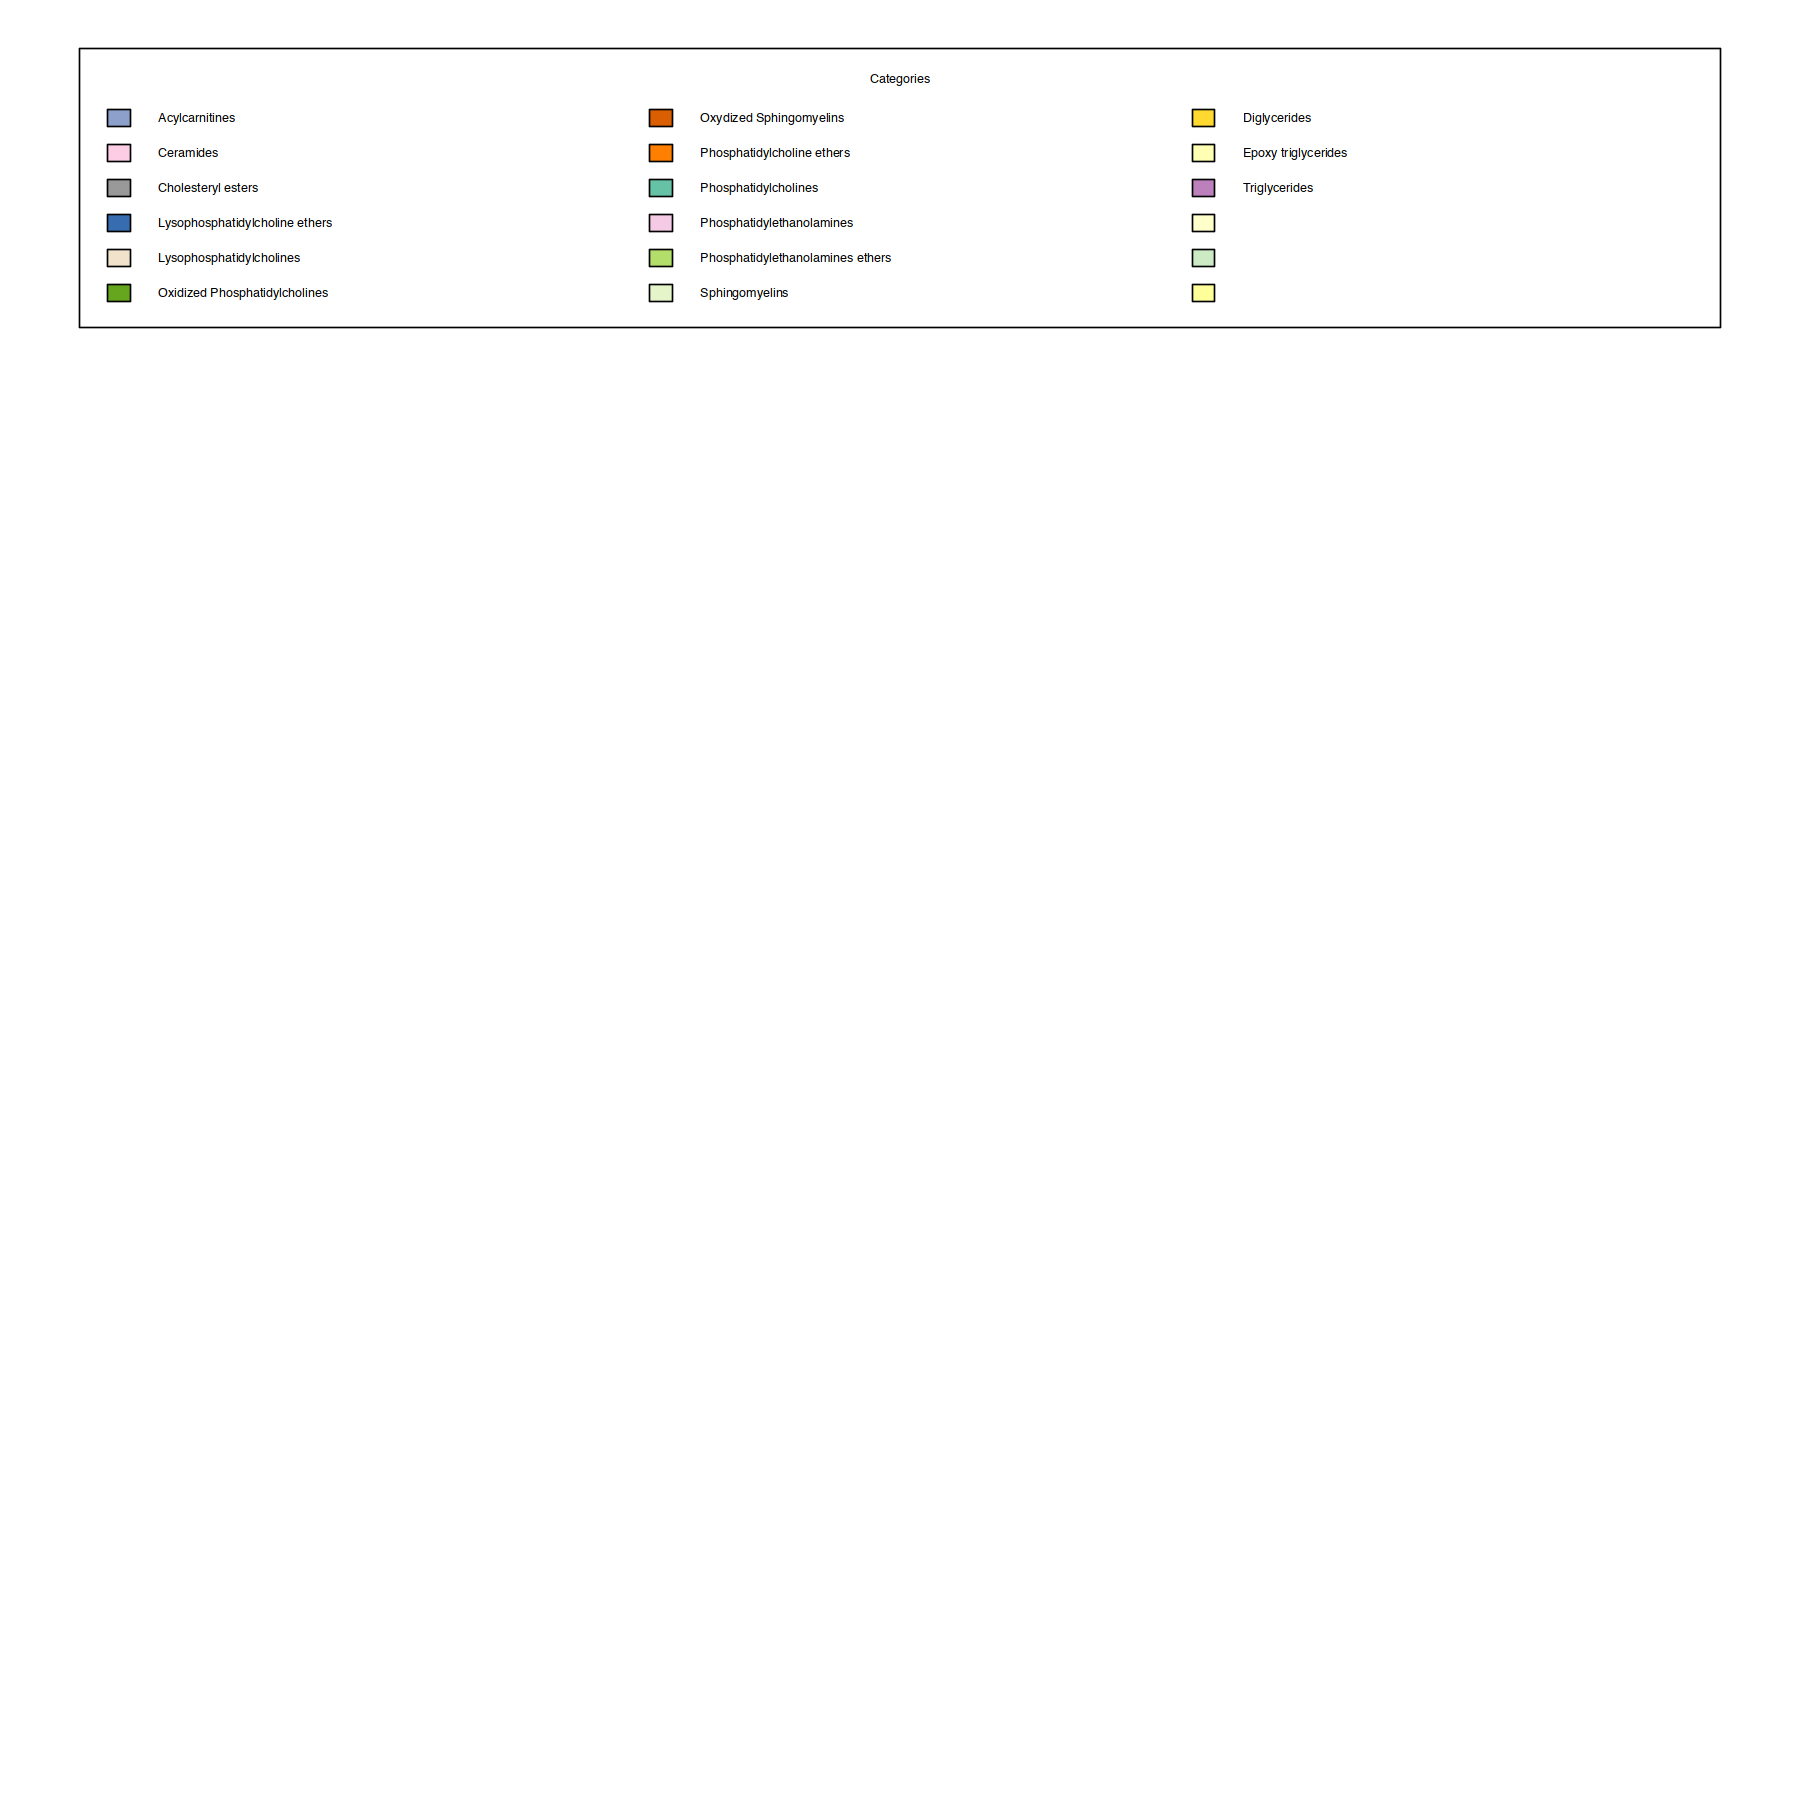

In [22]:
options(repr.plot.width = 15, repr.plot.height = 15)

step_model =  c('X1','X5','X19','X25','X32','X48','X58','X87','X92','X93','X94','X96','X97','X107','X112','X113','X121','X122','X127','X129','X141','X149','X152','X160','X166','X167','X181','X186','X190','X195','X197','X200','X201','X209','X213','X214','X226') 
border_col = c('1'='black','0'='white')
border_col_vec = border_col[as.character(as.numeric(rownames(mat)%in%step_model))]


vertex_size = c('1'=12,'0'=5)
vertex_size_vec = vertex_size[as.character(as.numeric(rownames(mat)%in%step_model))]

mat <- cor(scaled_df)
mat[mat<0.6] <- 0
network <- graph_from_adjacency_matrix(abs(mat), weighted=T, mode="undirected", diag=F)

c_scale <- colorRamp(rev(c('red','darkorange1','yellow','grey')))

E(network)$color = apply(c_scale(E(network)$weight), 1, function(x) rgb(x[1]/255,x[2]/255,x[3]/255) )
set.seed(123)                    
plot(network,

    # === vertex
    vertex.color=my_color,          # Node color
    vertex.frame.color = border_col_vec,                 # Node border color
    vertex.shape="circle",                        # One of “none”, “circle”, “square”, “csquare”, “rectangle” “crectangle”, “vrectangle”, “pie”, “raster”, or “sphere”
    vertex.size=vertex_size_vec,                               # Size of the node (default is 15)
    vertex.size2=NA,                              # The second size of the node (e.g. for a rectangle)

    # === vertex label
    vertex.label.color='white',
    vertex.label.family="Times",  
     # Font family of the label (e.g.“Times”, “Helvetica”)
    vertex.label.font=1,                          # Font: 1 plain, 2 bold, 3, italic, 4 bold italic, 5 symbol
    vertex.label.cex=1,                           # Font size (multiplication factor, device-dependent)
    vertex.label.dist=0,                          # Distance between the label and the vertex
    vertex.label.degree=0 ,                       # The position of the label in relation to the vertex (use pi)

    # === Edge
    edge.width=scale(edge.betweenness(network)),                                 # Edge width, defaults to 1
    edge.arrow.size=1,                            # Arrow size, defaults to 1
    edge.arrow.width=1,                           # Arrow width, defaults to 1
    edge.lty="solid",                             # Line type, could be 0 or “blank”, 1 or “solid”, 2 or “dashed”, 3 or “dotted”, 4 or “dotdash”, 5 or “longdash”, 6 or “twodash”
    edge.curved=0.3    ,                          # Edge curvature, range 0-1 (FALSE sets it to 0, TRUE to 0.5)
    )
par(mar = c(5, 5, 2, 5))  # Adjust the margin to leave space for the legend
# Plotting an empty plot to create space for the legend
plot(1, type = "n", axes = FALSE, xlab = "", ylab = "")
# Adding a legend
legend("top", legend = names(col_vector), fill = col_vector, title = "Categories",ncol = 3, cex = 0.6, xpd = TRUE)
   

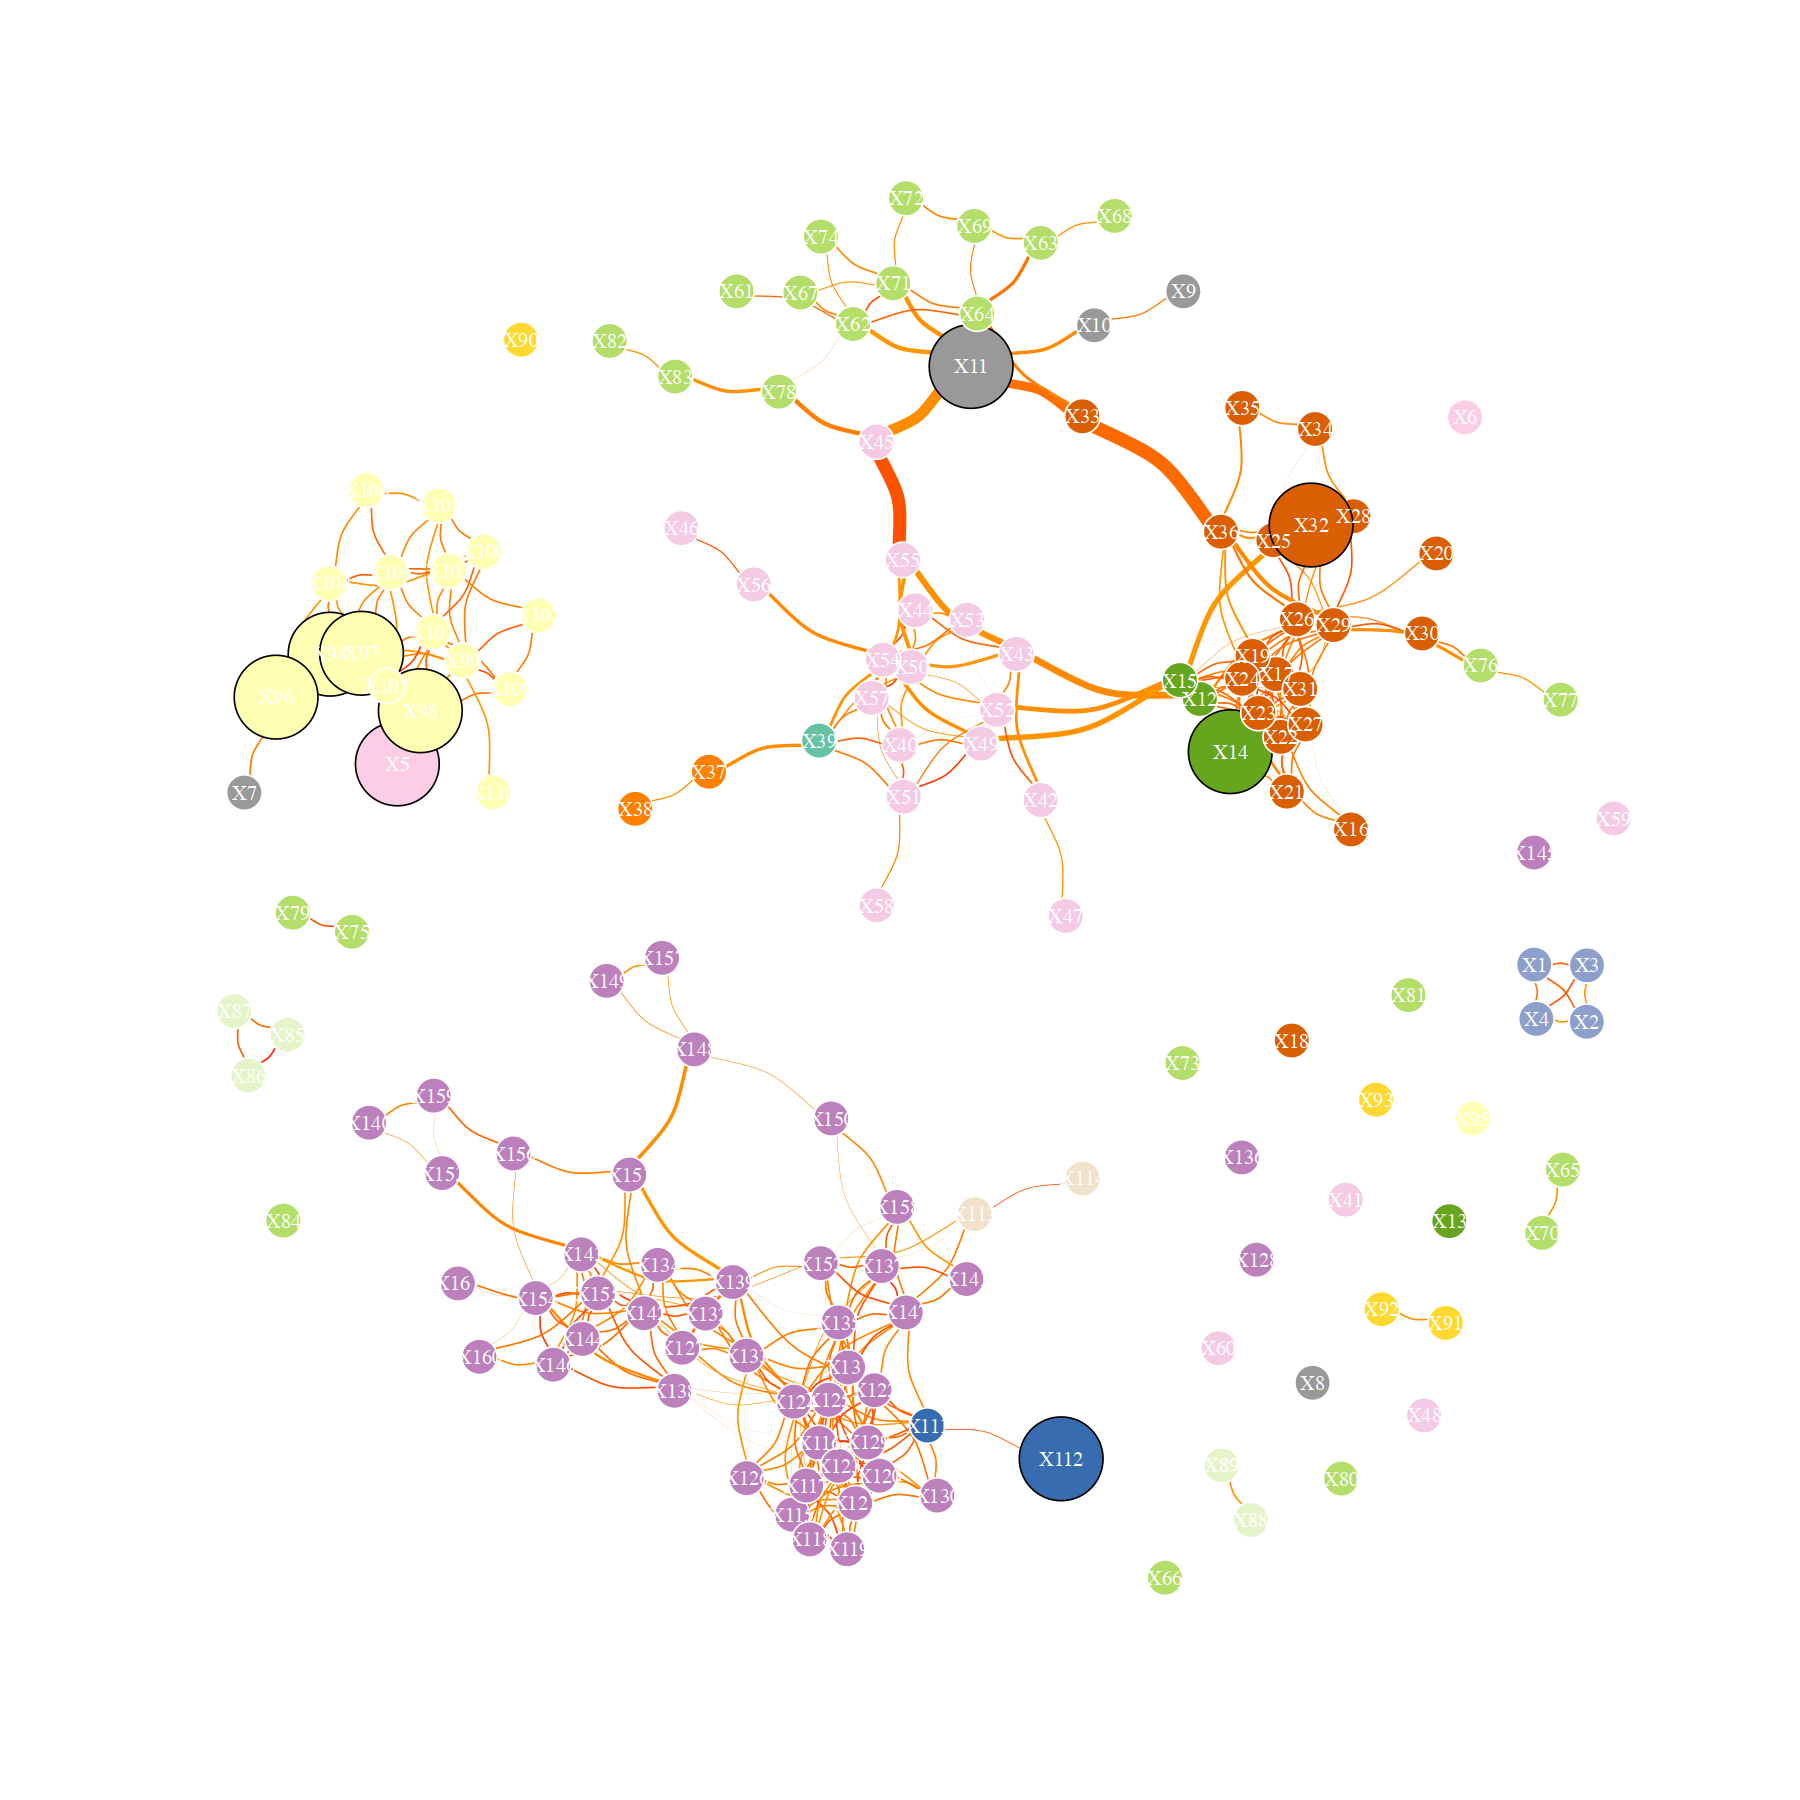

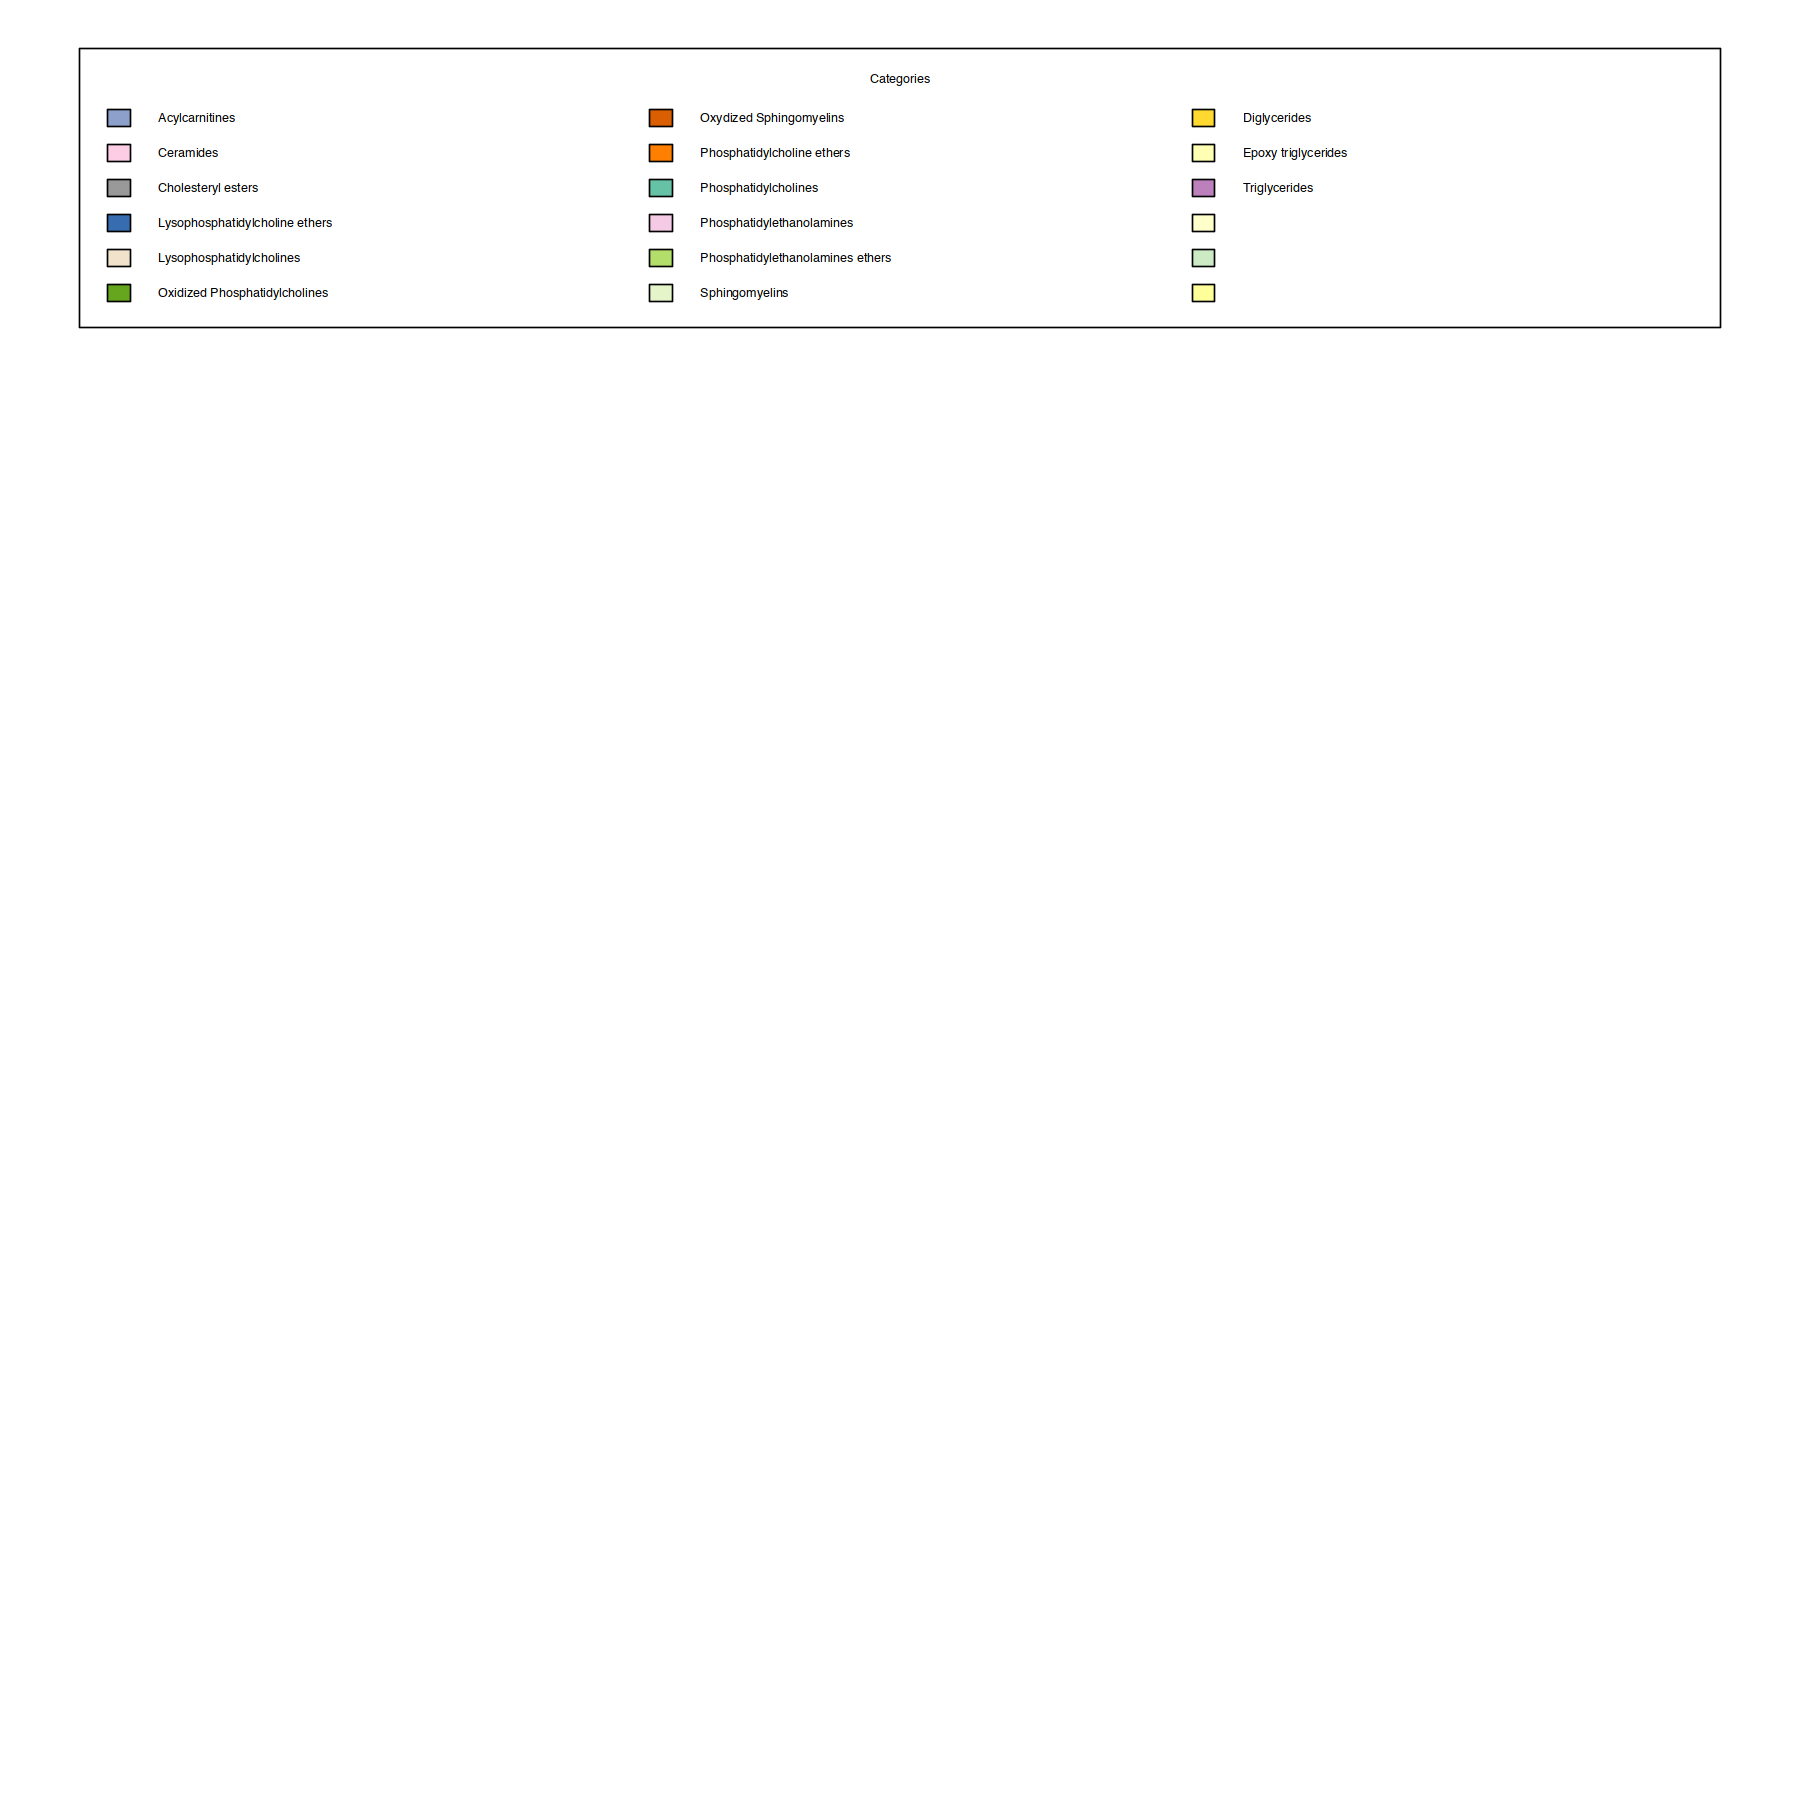

In [20]:
options(repr.plot.width = 15, repr.plot.height = 15)

se_lasso = c('X112','X97','X186','X197','X94','X11','X5','X14','X32','X96','X98','X190','X214','X233')
border_col = c('1'='black','0'='white')
border_col_vec = border_col[as.character(as.numeric(rownames(mat)%in%se_lasso))]


vertex_size = c('1'=12,'0'=5)
vertex_size_vec = vertex_size[as.character(as.numeric(rownames(mat)%in%se_lasso))]

mat <- cor(scaled_df)
mat[mat<0.6] <- 0
network <- graph_from_adjacency_matrix(abs(mat), weighted=T, mode="undirected", diag=F)

c_scale <- colorRamp(rev(c('red','darkorange1','yellow','grey')))

E(network)$color = apply(c_scale(E(network)$weight), 1, function(x) rgb(x[1]/255,x[2]/255,x[3]/255) )
                         
set.seed(123)                                        
plot(network,

    # === vertex
    vertex.color=my_color,          # Node color
    vertex.frame.color = border_col_vec,                 # Node border color
    vertex.shape="circle",                        # One of “none”, “circle”, “square”, “csquare”, “rectangle” “crectangle”, “vrectangle”, “pie”, “raster”, or “sphere”
    vertex.size=vertex_size_vec,                               # Size of the node (default is 15)
    vertex.size2=NA,                              # The second size of the node (e.g. for a rectangle)

    # === vertex label
    vertex.label.color='white',
    vertex.label.family="Times",  
     # Font family of the label (e.g.“Times”, “Helvetica”)
    vertex.label.font=1,                          # Font: 1 plain, 2 bold, 3, italic, 4 bold italic, 5 symbol
    vertex.label.cex=1,                           # Font size (multiplication factor, device-dependent)
    vertex.label.dist=0,                          # Distance between the label and the vertex
    vertex.label.degree=0 ,                       # The position of the label in relation to the vertex (use pi)

    # === Edge
    edge.width=scale(edge.betweenness(network)),                                 # Edge width, defaults to 1
    edge.arrow.size=1,                            # Arrow size, defaults to 1
    edge.arrow.width=1,                           # Arrow width, defaults to 1
    edge.lty="solid",                             # Line type, could be 0 or “blank”, 1 or “solid”, 2 or “dashed”, 3 or “dotted”, 4 or “dotdash”, 5 or “longdash”, 6 or “twodash”
    edge.curved=0.3    ,                          # Edge curvature, range 0-1 (FALSE sets it to 0, TRUE to 0.5)
    )
par(mar = c(5, 5, 2, 5))  # Adjust the margin to leave space for the legend
# Plotting an empty plot to create space for the legend
plot(1, type = "n", axes = FALSE, xlab = "", ylab = "")
# Adding a legend
legend("top", legend = names(col_vector), fill = col_vector, title = "Categories",ncol = 3, cex = 0.6, xpd = TRUE)
   

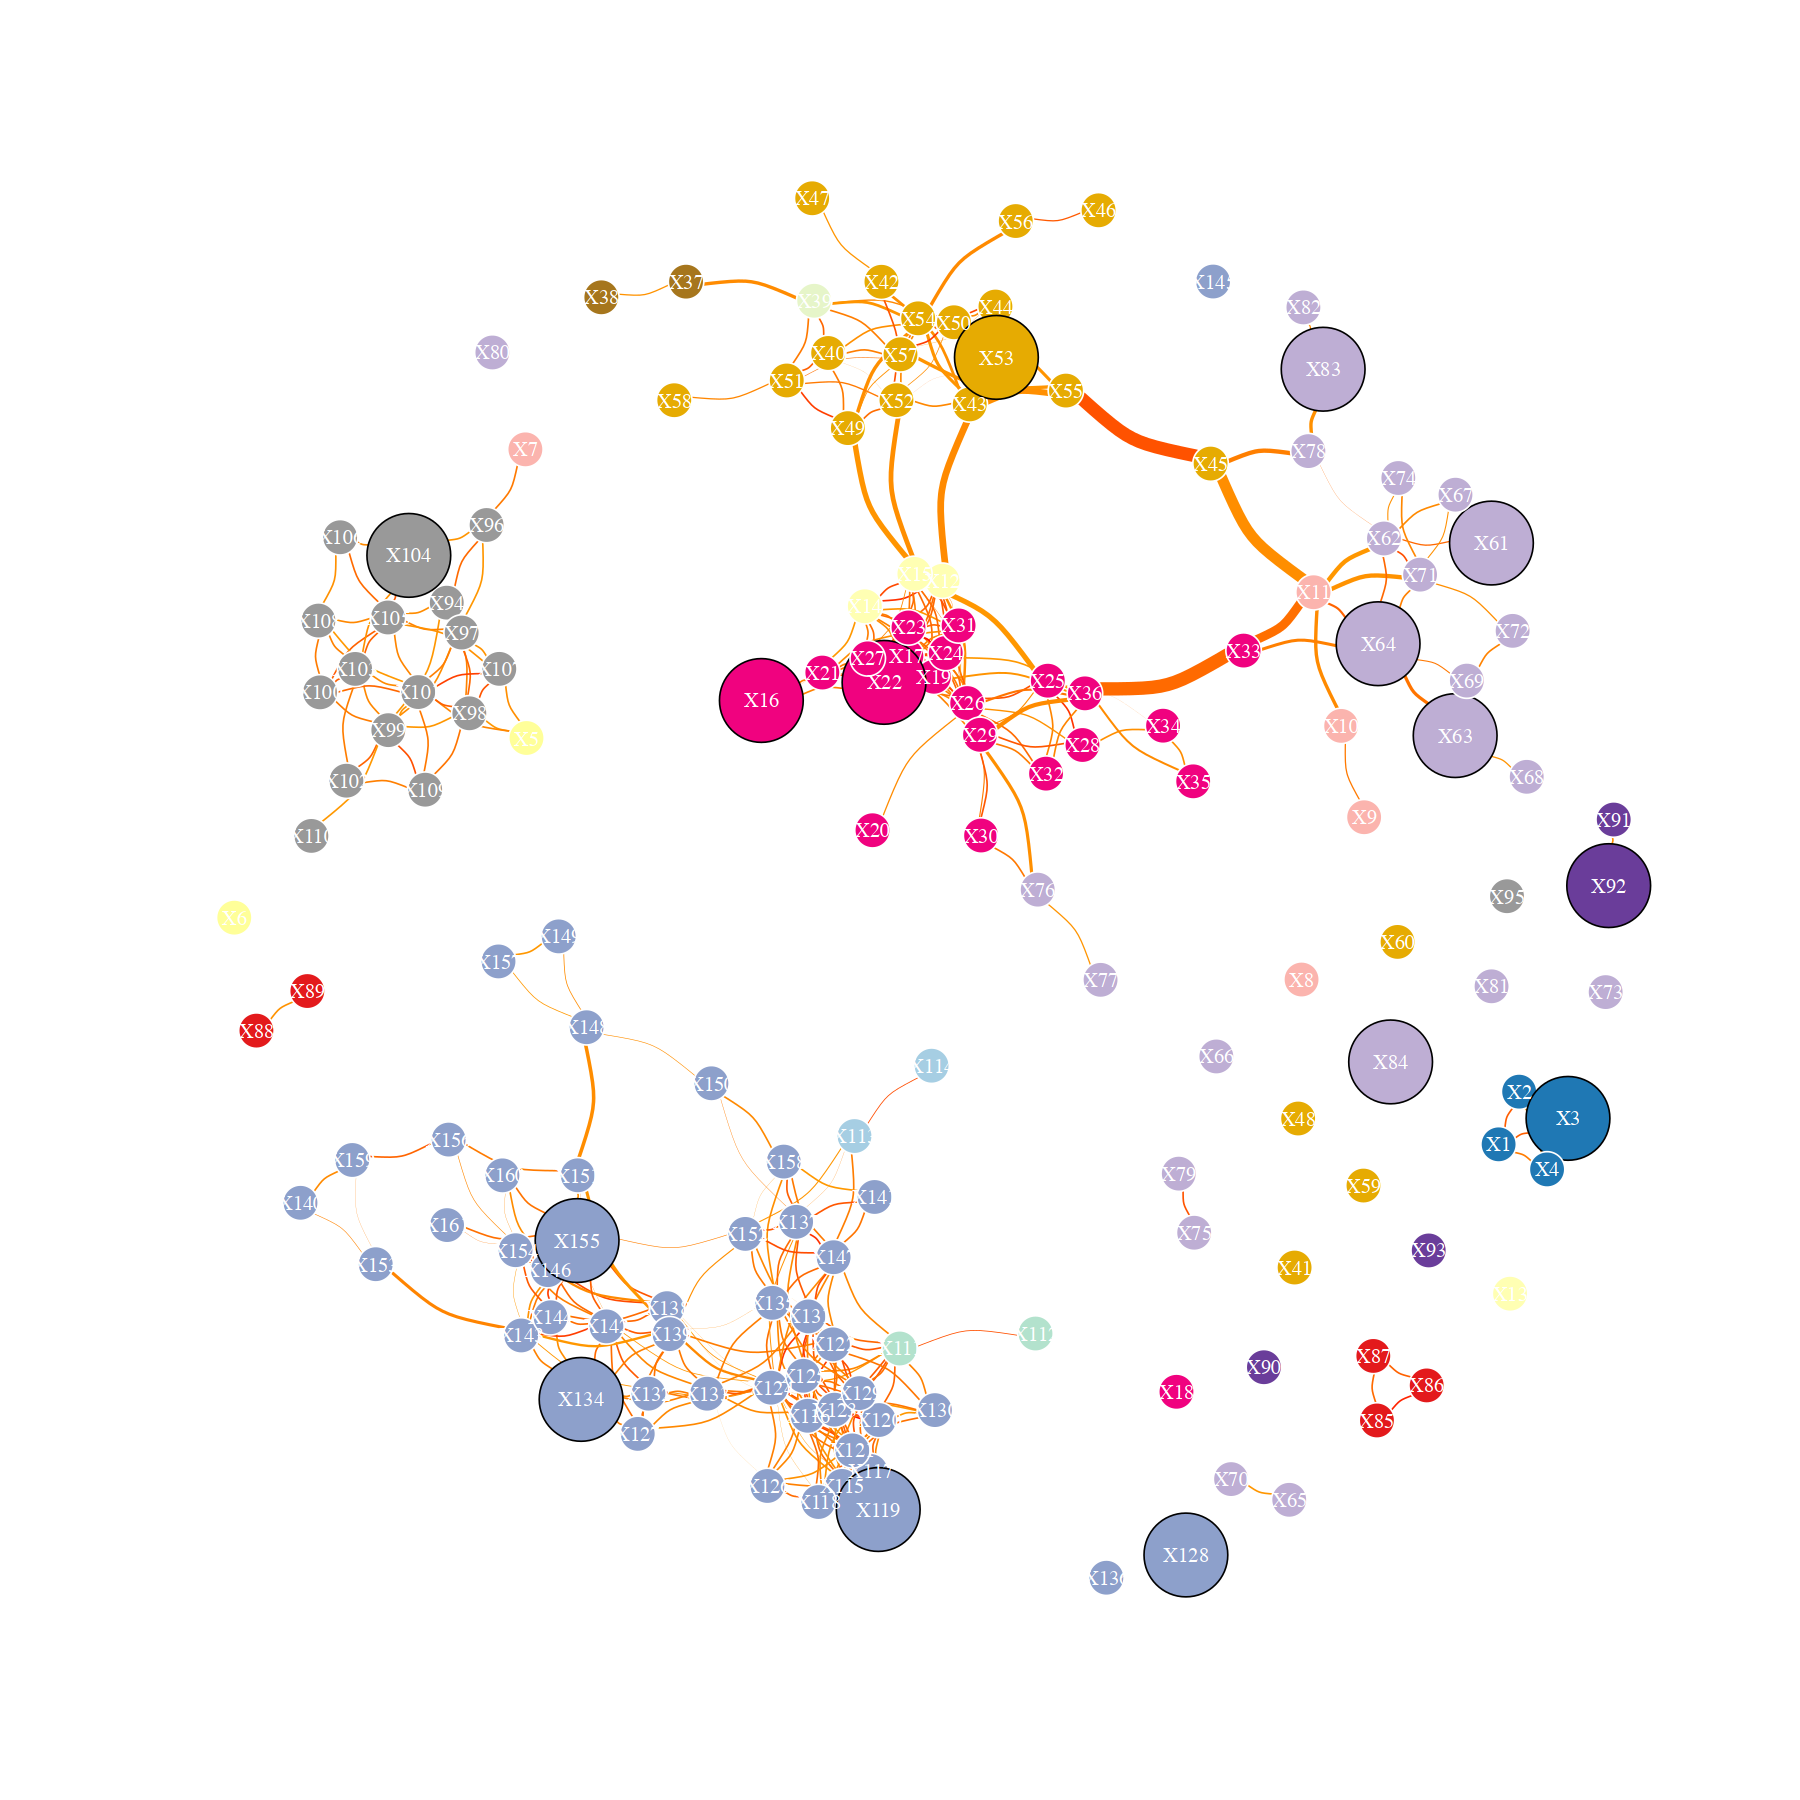

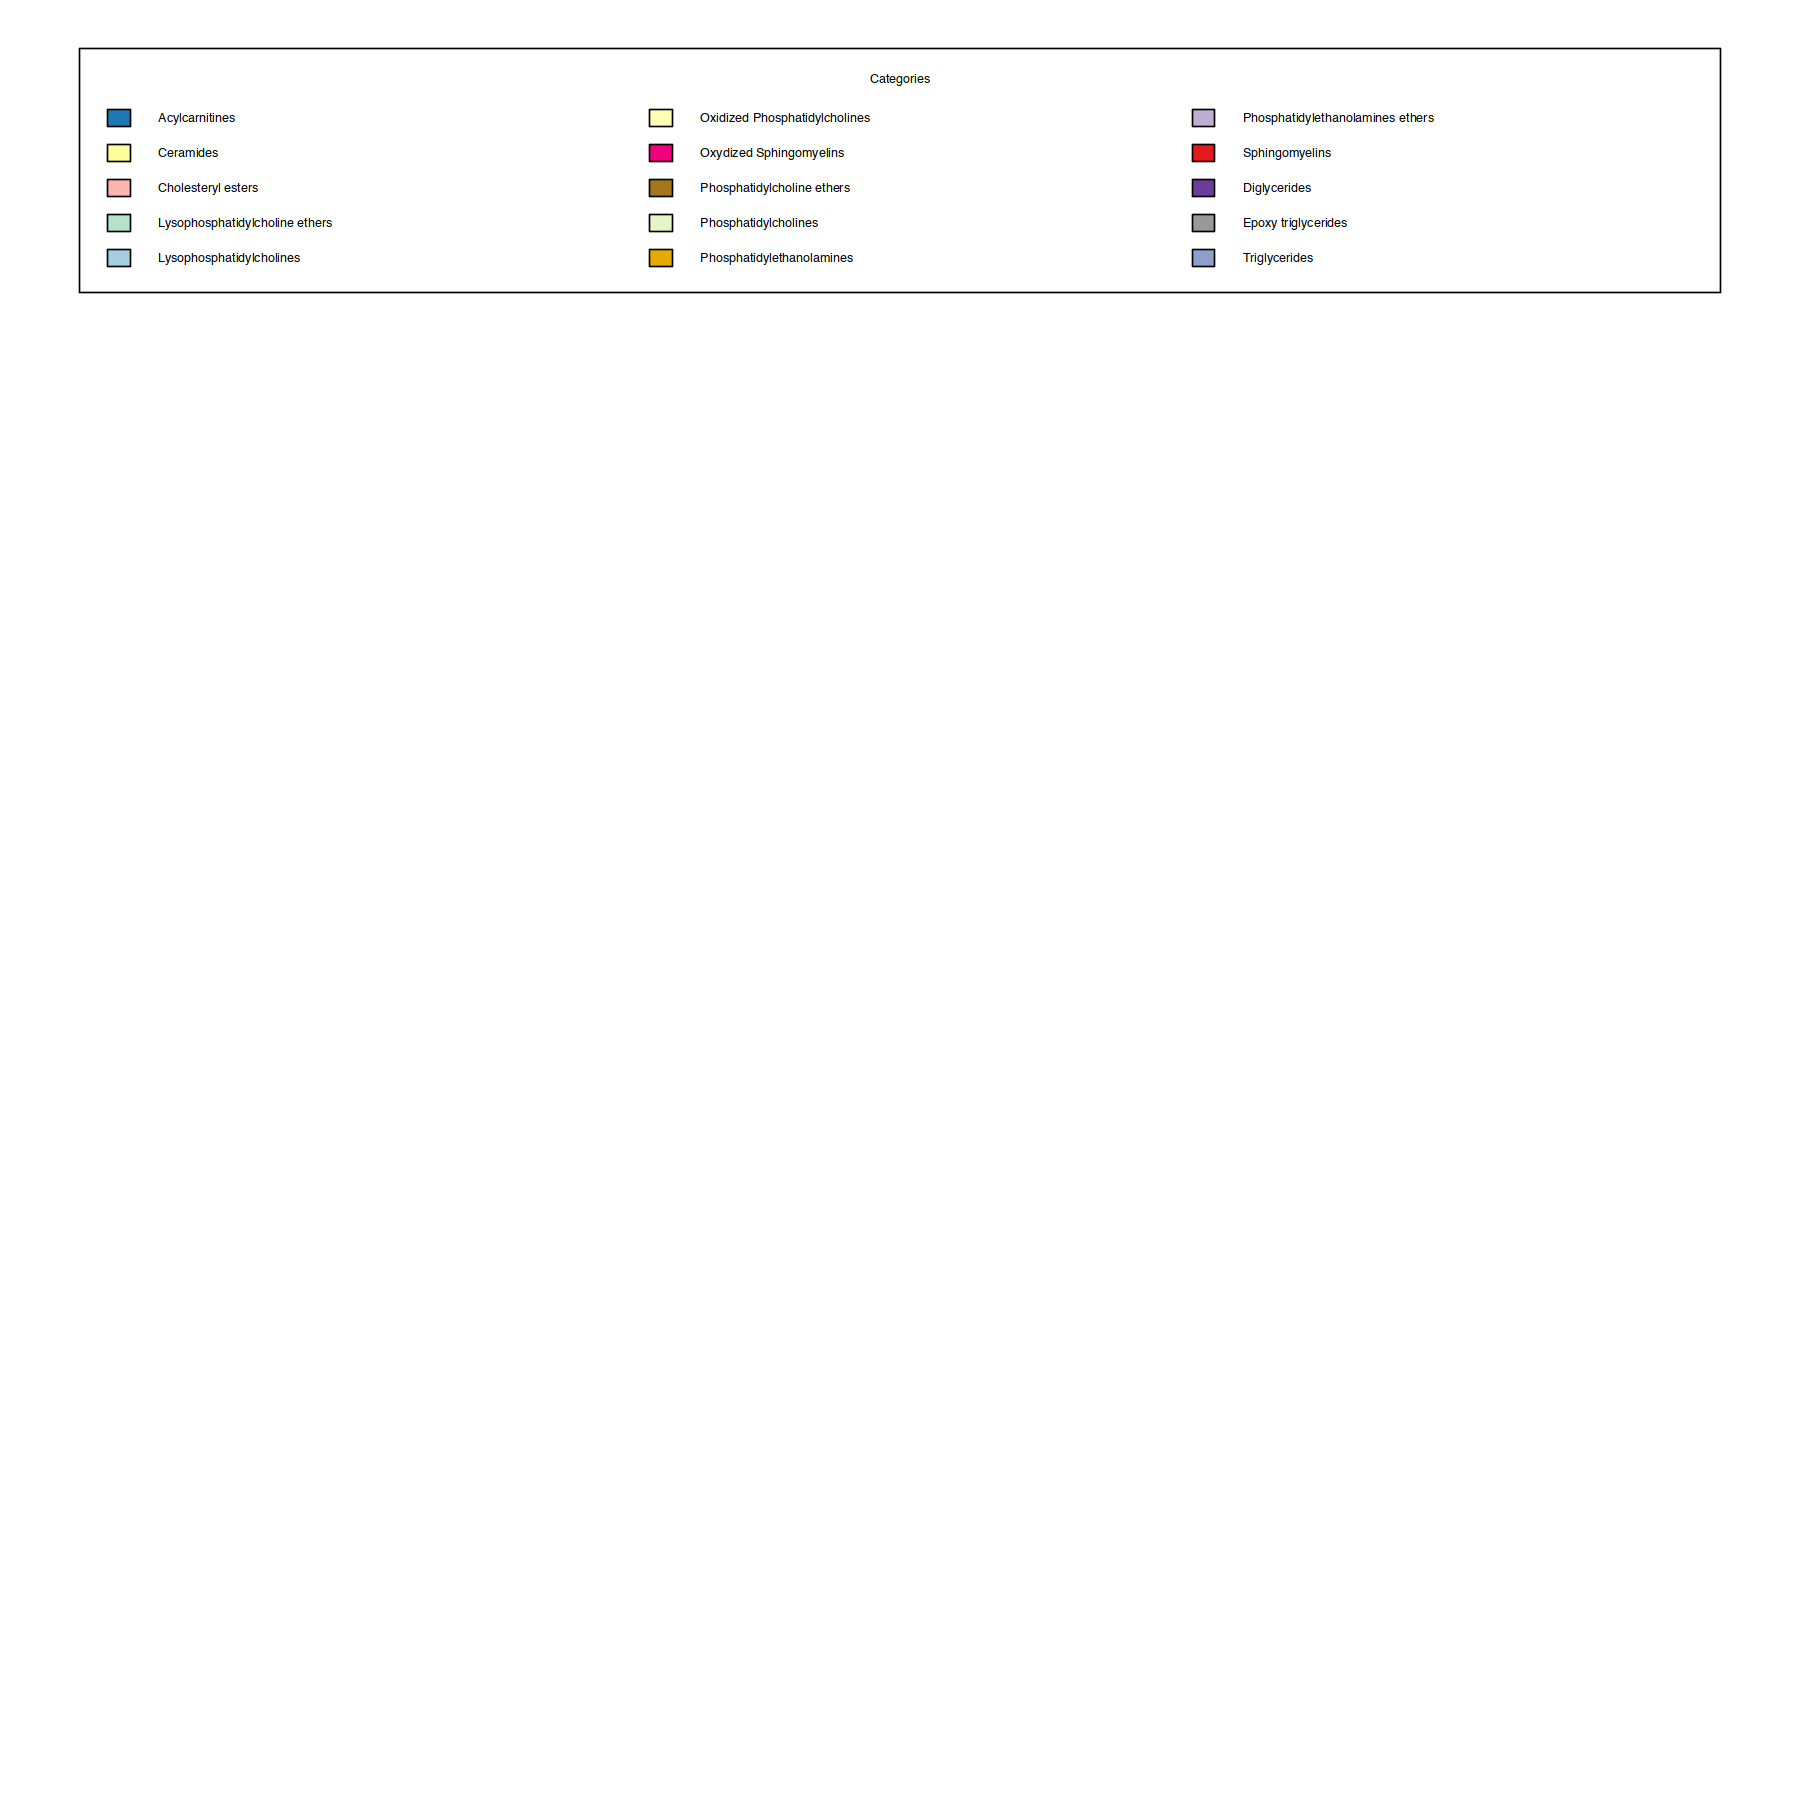

In [132]:

options(repr.plot.width = 15, repr.plot.height = 15)

rf_minimal = c('X64','X134','X128','X83','X3','X63','X53','X61','X16','X84','X104','X155','X119','X22','X92')
border_col = c('1'='black','0'='white')
border_col_vec = border_col[as.character(as.numeric(rownames(mat)%in%rf_minimal))]


vertex_size = c('1'=12,'0'=5)
vertex_size_vec = vertex_size[as.character(as.numeric(rownames(mat)%in%rf_minimal))]

mat <- cor(scaled_df)
mat[mat<0.6] <- 0
network <- graph_from_adjacency_matrix(abs(mat), weighted=T, mode="undirected", diag=F)

c_scale <- colorRamp(rev(c('red','darkorange1','yellow','grey')))

E(network)$color = apply(c_scale(E(network)$weight), 1, function(x) rgb(x[1]/255,x[2]/255,x[3]/255) )
                         
set.seed(123)                                        
plot(network,

    # === vertex
    vertex.color=my_color,          # Node color
    vertex.frame.color = border_col_vec,                 # Node border color
    vertex.shape="circle",                        # One of “none”, “circle”, “square”, “csquare”, “rectangle” “crectangle”, “vrectangle”, “pie”, “raster”, or “sphere”
    vertex.size=vertex_size_vec,                               # Size of the node (default is 15)
    vertex.size2=NA,                              # The second size of the node (e.g. for a rectangle)

    # === vertex label
    vertex.label.color='white',
    vertex.label.family="Times",  
     # Font family of the label (e.g.“Times”, “Helvetica”)
    vertex.label.font=1,                          # Font: 1 plain, 2 bold, 3, italic, 4 bold italic, 5 symbol
    vertex.label.cex=1,                           # Font size (multiplication factor, device-dependent)
    vertex.label.dist=0,                          # Distance between the label and the vertex
    vertex.label.degree=0 ,                       # The position of the label in relation to the vertex (use pi)

    # === Edge
    edge.width=scale(edge.betweenness(network)),                                 # Edge width, defaults to 1
    edge.arrow.size=1,                            # Arrow size, defaults to 1
    edge.arrow.width=1,                           # Arrow width, defaults to 1
    edge.lty="solid",                             # Line type, could be 0 or “blank”, 1 or “solid”, 2 or “dashed”, 3 or “dotted”, 4 or “dotdash”, 5 or “longdash”, 6 or “twodash”
    edge.curved=0.3    ,                          # Edge curvature, range 0-1 (FALSE sets it to 0, TRUE to 0.5)
    )
par(mar = c(5, 5, 2, 5))  # Adjust the margin to leave space for the legend
# Plotting an empty plot to create space for the legend
plot(1, type = "n", axes = FALSE, xlab = "", ylab = "")
# Adding a legend
legend("top", legend = names(col_vector), fill = col_vector, title = "Categories",ncol = 3, cex = 0.6, xpd = TRUE)
   

In [127]:
sizes = importance[rownames(mat),'MeanDecreaseGini']

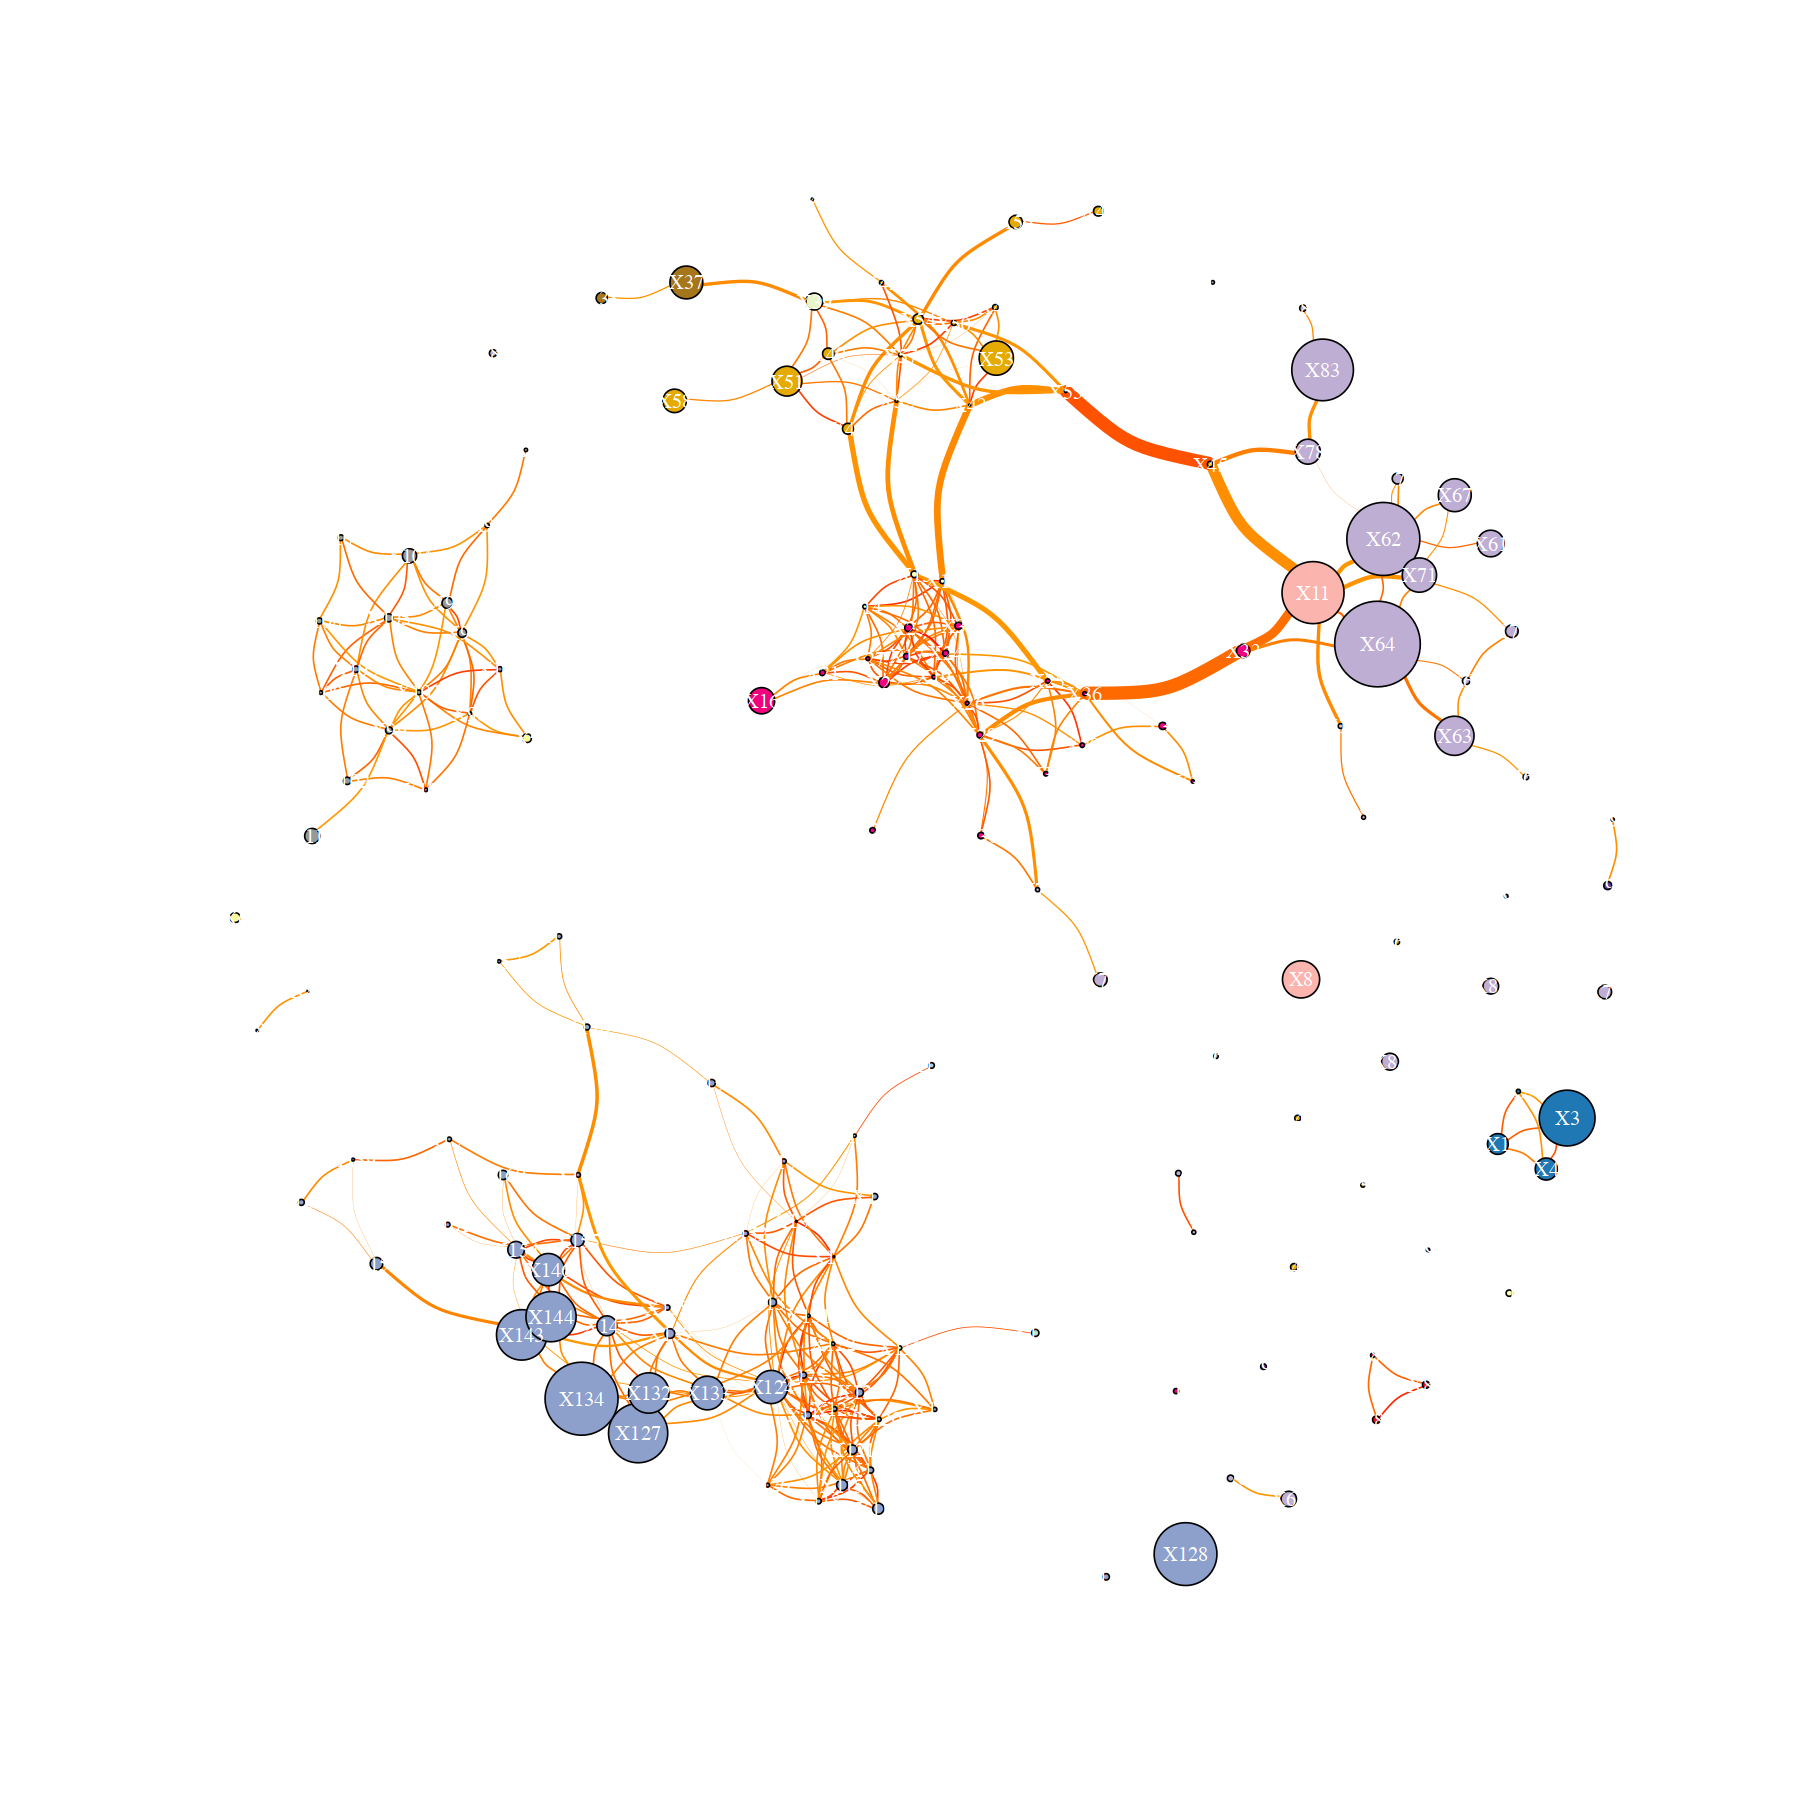

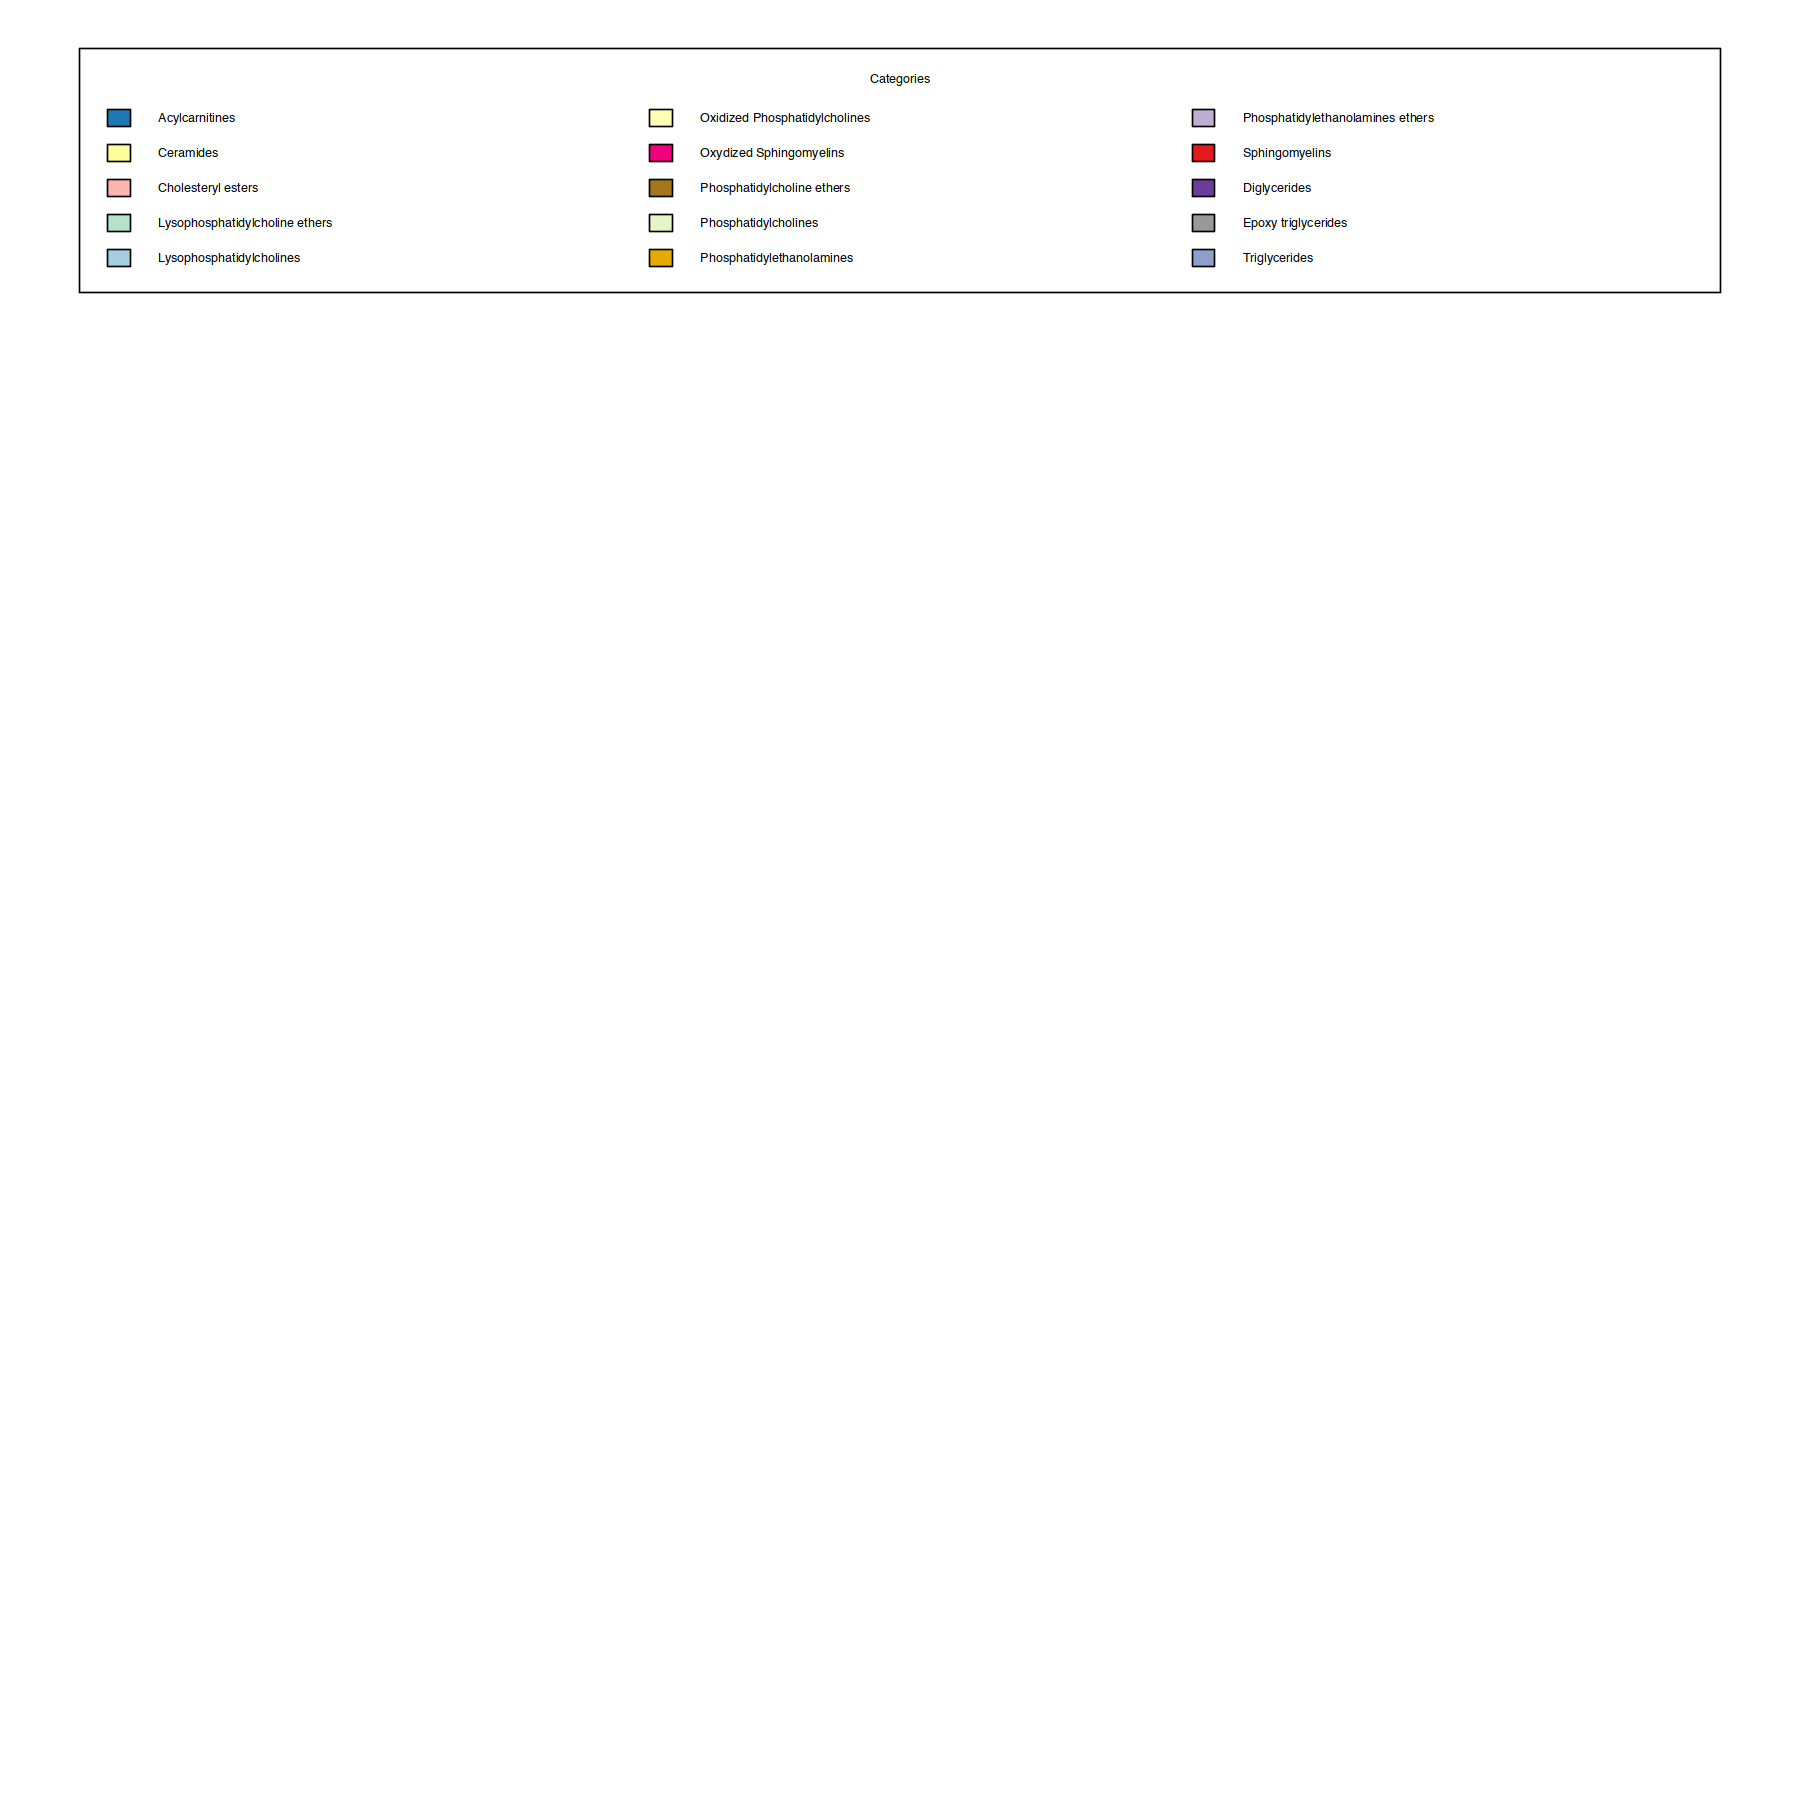

In [131]:

options(repr.plot.width = 15, repr.plot.height = 15)

rf_minimal = c('X64','X134','X3','X53','X16','X84','X155','X119','X22','X92')
border_col = c('1'='black','0'='white')
border_col_vec = border_col[as.character(as.numeric(rownames(mat)%in%rf_minimal))]


vertex_size = c('1'=12,'0'=5)
vertex_size_vec = vertex_size[as.character(as.numeric(rownames(mat)%in%rf_minimal))]

mat <- cor(scaled_df)
mat[mat<0.6] <- 0
network <- graph_from_adjacency_matrix(abs(mat), weighted=T, mode="undirected", diag=F)

c_scale <- colorRamp(rev(c('red','darkorange1','yellow','grey')))

E(network)$color = apply(c_scale(E(network)$weight), 1, function(x) rgb(x[1]/255,x[2]/255,x[3]/255) )
                         
set.seed(123)                                        
plot(network,

    # === vertex
    vertex.color=my_color,          # Node color
    vertex.frame.color = 'black',                 # Node border color
    vertex.shape="circle",                        # One of “none”, “circle”, “square”, “csquare”, “rectangle” “crectangle”, “vrectangle”, “pie”, “raster”, or “sphere”
    vertex.size=sizes*10,                               # Size of the node (default is 15)
    vertex.size2=NA,                              # The second size of the node (e.g. for a rectangle)

    # === vertex label
    vertex.label.color='white',
    vertex.label.family="Times",  
     # Font family of the label (e.g.“Times”, “Helvetica”)
    vertex.label.font=1,                          # Font: 1 plain, 2 bold, 3, italic, 4 bold italic, 5 symbol
    vertex.label.cex=1,                           # Font size (multiplication factor, device-dependent)
    vertex.label.dist=0,                          # Distance between the label and the vertex
    vertex.label.degree=0 ,                       # The position of the label in relation to the vertex (use pi)

    # === Edge
    edge.width=scale(edge.betweenness(network)),                                 # Edge width, defaults to 1
    edge.arrow.size=1,                            # Arrow size, defaults to 1
    edge.arrow.width=1,                           # Arrow width, defaults to 1
    edge.lty="solid",                             # Line type, could be 0 or “blank”, 1 or “solid”, 2 or “dashed”, 3 or “dotted”, 4 or “dotdash”, 5 or “longdash”, 6 or “twodash”
    edge.curved=0.3    ,                          # Edge curvature, range 0-1 (FALSE sets it to 0, TRUE to 0.5)
    )
par(mar = c(5, 5, 2, 5))  # Adjust the margin to leave space for the legend
# Plotting an empty plot to create space for the legend
plot(1, type = "n", axes = FALSE, xlab = "", ylab = "")
# Adding a legend
legend("top", legend = names(col_vector), fill = col_vector, title = "Categories",ncol = 3, cex = 0.6, xpd = TRUE)
   

In [142]:
importance[c('X16','X3','X104','X132','X134','X128','X84','X92','X58','X53','X64'),]

,MeanDecreaseGini,lipid_id_became,lipid_id_miracle,lipid_class,modified_became_id
,<dbl>,<chr>,<chr>,<chr>,<chr>
X16,0.3673183,LPC15:0,LPC15:0,Lysophosphatidylcholines,LPC15:0
X3,0.7955803,C18:1 Car,C18:1 Car,Acylcarnitines,C18:1 Car
X104,0.1913969,SM(d18:2/23:0),SM(d18:2/14:0),Sphingomyelins,SM(d18:2/23:0)
X132,0.5717907,TG52:5,TG52:5,Triglycerides,TG52:5
X134,1.0450756,TG52:7,TG52:7,Triglycerides,TG52:7
X128,0.8974910,TG50:6,TG50:6,Triglycerides,TG50:6
X84,0.2306884,PE(O-16:0/20:4),PC(22:6_20:4),Phosphatidylcholines,PE(O-16:0/20:4)
X92,0.1021478,PE(18:1_18:0),PE(O-18:1/18:2),Phosphatidylethanolamines ethers,PE(18:1_18:0)
X58,0.3266087,PC(O-20:2/20:4),PC(O-20:0/20:4),Phosphatidylcholine ethers,PC(O-20:2/20:4)
